In [17]:
import xarray as xr
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

path = r'/Users/eunbumkim/Documents/practice/data/NetCDF'
filename = path + r'/gk2aamile1bsw038ko020lc202510171520.nc'

# 1) NetCDF 읽기
ds = xr.open_dataset(filename)
ds                  # Jupyter에서 셀 마지막에 두면 HTML 요약 출력

<xarray.Dataset> Size: 2MB
Dimensions:             (dim_y: 900, dim_x: 900)
Dimensions without coordinates: dim_y, dim_x
Data variables:
    image_pixel_values  (dim_y, dim_x) uint16 2MB ...
Attributes: (12/32)
    projection_type:             lambert_conformal_conic
    standard_parallel1:          30.0
    standard_parallel2:          60.0
    origin_latitude:             38.0
    central_meridian:            126.0
    false_easting:               0.0
    ...                          ...
    channel_spatial_resolution:  2.0
    data_processing_center:      NMSC
    data_processing_mode:        operation
    file_format_version:         1.0.0_20181120
    instrument_name:             AMI
    satellite_name:              GK-2A

In [18]:
print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:             (dim_y: 900, dim_x: 900)
Dimensions without coordinates: dim_y, dim_x
Data variables:
    image_pixel_values  (dim_y, dim_x) uint16 2MB ...
Attributes: (12/32)
    projection_type:             lambert_conformal_conic
    standard_parallel1:          30.0
    standard_parallel2:          60.0
    origin_latitude:             38.0
    central_meridian:            126.0
    false_easting:               0.0
    ...                          ...
    channel_spatial_resolution:  2.0
    data_processing_center:      NMSC
    data_processing_mode:        operation
    file_format_version:         1.0.0_20181120
    instrument_name:             AMI
    satellite_name:              GK-2A


In [19]:
# dimensions/coords/variables/attrs 상세 출력
ds.info()

xarray.Dataset {
dimensions:
	dim_y = 900 ;
	dim_x = 900 ;

variables:
	uint16 image_pixel_values(dim_y, dim_x) ;
		image_pixel_values:number_of_total_pixels = 810000 ;
		image_pixel_values:average_pixel_value = 16032.328985964912 ;
		image_pixel_values:channel_name = SW038 ;
		image_pixel_values:max_pixel_value = 16345 ;
		image_pixel_values:min_pixel_value = 15616 ;
		image_pixel_values:number_of_total_bits_per_pixel = 16 ;
		image_pixel_values:number_of_valid_bits_per_pixel = 14 ;

// global attributes:
	:projection_type = lambert_conformal_conic ;
	:standard_parallel1 = 30.0 ;
	:standard_parallel2 = 60.0 ;
	:origin_latitude = 38.0 ;
	:central_meridian = 126.0 ;
	:false_easting = 0.0 ;
	:false_northing = 0.0 ;
	:image_width = 900 ;
	:image_height = 900 ;
	:pixel_size = 2000.0 ;
	:upper_left_easting = -899000.0 ;
	:upper_left_northing = 899000.0 ;
	:upper_right_easting = 899000.0 ;
	:upper_right_northing = 899000.0 ;
	:lower_left_easting = -899000.0 ;
	:lower_left_northing = -899000.

In [20]:
# 2. 핵심 구성요소 확인

print(ds.dims)             # 차원(이름: 길이)  예: {'x': 900, 'y': 900}
print(ds.coords)           # 좌표 변수
print(ds.data_vars)        # 데이터 변수 목록
print(list(ds.variables))  # 모든 변수 이름
print(ds.sizes)            # 차원별 크기 (dims 권장 대체)

FrozenMappingWarningOnValuesAccess({'dim_y': 900, 'dim_x': 900})
Coordinates:
    *empty*
Data variables:
    image_pixel_values  (dim_y, dim_x) uint16 2MB ...
['image_pixel_values']
Frozen({'dim_y': 900, 'dim_x': 900})


In [21]:
# 특정 변수의 속성 (단위, scale_factor, _FillValue 등)
ds['image_pixel_values'].attrs

{'number_of_total_pixels': 810000,
 'average_pixel_value': 16032.328985964912,
 'channel_name': 'SW038',
 'max_pixel_value': 16345,
 'min_pixel_value': 15616,
 'number_of_total_bits_per_pixel': 16,
 'number_of_valid_bits_per_pixel': 14}

In [22]:
import netCDF4
nc = netCDF4.Dataset(filename)
print(nc.groups)      # 그룹이 있으면 group= 인자로 다시 open
print(nc.ncattrs())   # 전역 속성

{}
['projection_type', 'standard_parallel1', 'standard_parallel2', 'origin_latitude', 'central_meridian', 'false_easting', 'false_northing', 'image_width', 'image_height', 'pixel_size', 'upper_left_easting', 'upper_left_northing', 'upper_right_easting', 'upper_right_northing', 'lower_left_easting', 'lower_left_northing', 'lower_right_easting', 'lower_right_northing', '_CoordinateTransformType', '_CoordinateAxisTypes', 'file_name', 'origianl_sourece_file', 'number_of_columns', 'number_of_lines', 'total_pixel_data_size', 'channel_center_wavelength', 'channel_spatial_resolution', 'data_processing_center', 'data_processing_mode', 'file_format_version', 'instrument_name', 'satellite_name']


shape: (900, 900) dtype: uint16
min: 15643 max: 16339 mean: 16134.9


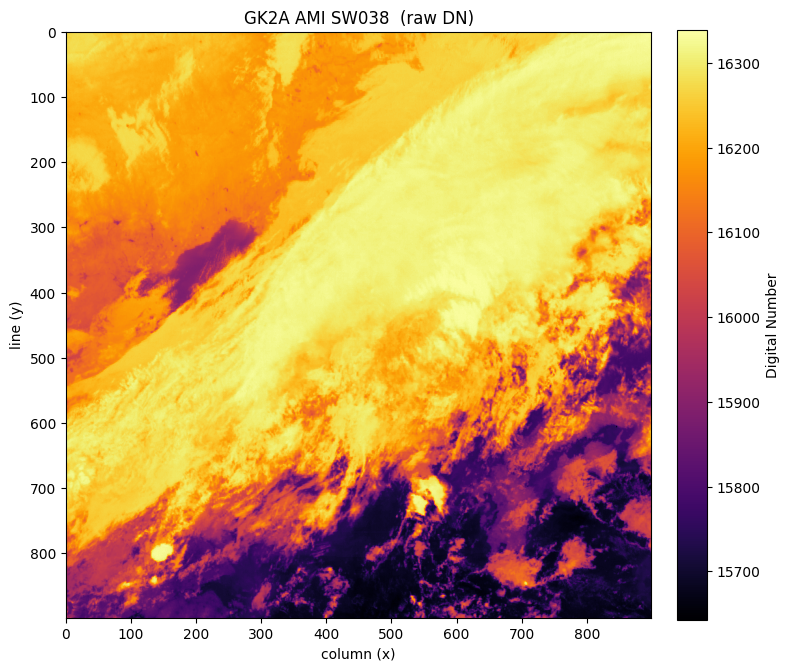

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.close('all')   # 이전 실행에서 남은 figure 정리 (중복 출력 방지)

# 픽셀 데이터 추출 (uint16, 14-bit DN: 약 15616 ~ 16345)
img = ds['image_pixel_values'].values

print('shape:', img.shape, 'dtype:', img.dtype)
vmin=img.min()
vmax=img.max()
print('min:', vmin, 'max:', vmax, f'mean: {img.mean():.1f}')

# matplotlib로 출력
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(img, cmap='inferno', origin='upper', vmin=vmin, vmax=vmax)
ax.set_title(f"GK2A AMI {ds['image_pixel_values'].attrs.get('channel_name', '')}  (raw DN)")
ax.set_xlabel('column (x)')
ax.set_ylabel('line (y)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Digital Number')
plt.tight_layout()
plt.show()
